# 🕵🏼‍♀️ Análisis Bivariado 🐧🐧

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

#Carga del dataset desde archivo local
df = pd.read_csv('../02_limpieza/penguins_limpio.csv')

## Qué variables vamos a analizar
- Relación de masa corporal por especie
- Relación de especie por islas
- Diferencias morfológicas (longitud del pico, profundidad del pico, longitud de aleta y masa corporal)

### Estudio de masa corporal de cada una de las especies

In [ ]:
# Estadísticas por grupo
df.groupby('Species')['Body Mass (g)'].agg(['mean', 'median', 'std'])

,mean,median,std
Species,,,
Adelie Penguin (Pygoscelis adeliae),3703.723404,3700.0,460.463045
Chinstrap penguin (Pygoscelis antarctica),3729.850746,3700.0,386.300411
Gentoo penguin (Pygoscelis papua),5074.590164,5000.0,505.945882


In [4]:
# Prueba estadística (ANOVA)
from scipy.stats import f_oneway
grupos = [df[df['Species'] == cat]['Body Mass (g)'] for cat in df['Species'].unique()]
f_stat, p_value = f_oneway(*grupos)
print(f"P-value: {p_value:.4f}")

P-value: 0.0000


El p-value nos indica que **existe una relación** entre la masa corporal y las especies (p-value < 0.05: bajo - resultado estadísticamente significativo). 

### Estudio de relación de especie por isla

In [5]:
# Tabla cruzada
pd.crosstab(df['Species'], df['Island'])

Island,Biscoe,Dream,Torgersen
Species,,,
Adelie Penguin (Pygoscelis adeliae),44,52,45
Chinstrap penguin (Pygoscelis antarctica),0,67,0
Gentoo penguin (Pygoscelis papua),122,0,0


In [6]:
# Con proporciones
pd.crosstab(df['Species'], df['Island'], normalize='all')

Island,Biscoe,Dream,Torgersen
Species,,,
Adelie Penguin (Pygoscelis adeliae),0.133333,0.157576,0.136364
Chinstrap penguin (Pygoscelis antarctica),0.000000,0.203030,0.000000
Gentoo penguin (Pygoscelis papua),0.369697,0.000000,0.000000


c:\Bootcam\Proyecto_Pinguinos\pinguinos\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


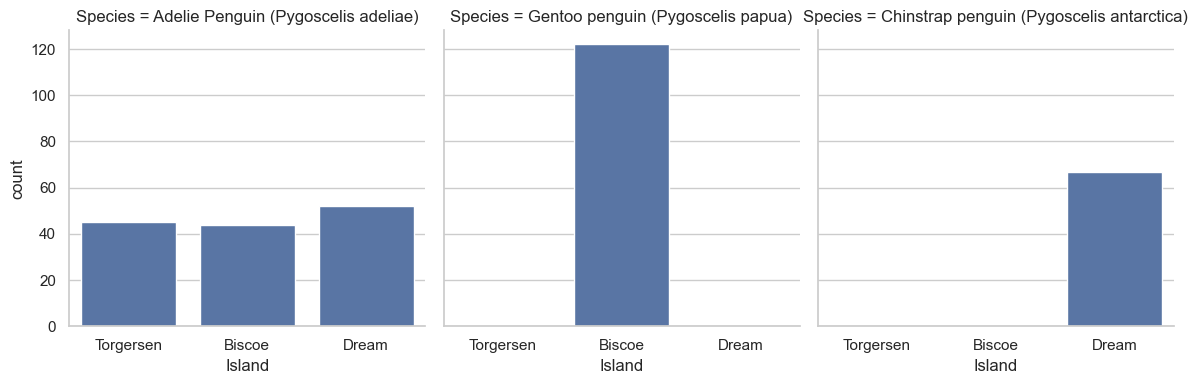

In [2]:
g = sns.FacetGrid(df, col='Species', height=4)
g.map(sns.countplot, 'Island')
plt.show()

La especie "Adelie Penguin" se encuentra de manera proporcional en las tres islas.    

En cambio, las especies "Chinstrap penguin" y "Gentooo penguin" solo en una isla: 
 - El 100% de los pingüinos "Chinstrap penguin" analizados se encuentran en la isla Dream.
 - El 100% de los pingüinos "Gentooo penguin" analizados se encuentran en la isla Biscoe.

### Matriz de Correlación

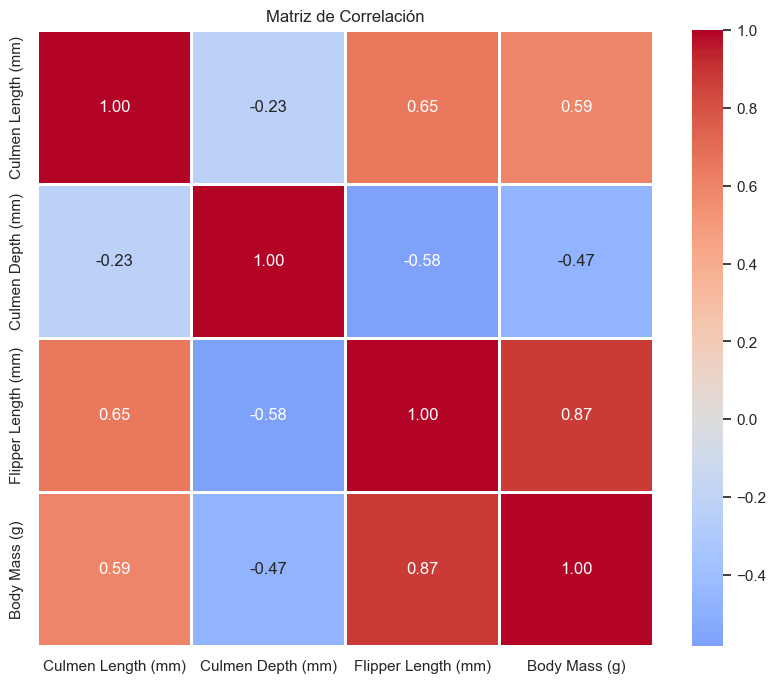

In [10]:
import numpy as np
# Solo numéricas
cols = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', "Body Mass (g)"]
corr = df[cols].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

Observando estas correlaciones, decidimos analizarlas más detalladamente por especie. 

### Relación entre longitud de pico y masa corporal por especie

In [5]:
correlacion_por_especie = df.groupby('Species')[['Culmen Length (mm)', 'Body Mass (g)']].corr().iloc[0::2, -1]

print(correlacion_por_especie)

Species                                                      
Adelie Penguin (Pygoscelis adeliae)        Culmen Length (mm)    0.569243
Chinstrap penguin (Pygoscelis antarctica)  Culmen Length (mm)    0.510282
Gentoo penguin (Pygoscelis papua)          Culmen Length (mm)    0.669698
Name: Body Mass (g), dtype: float64


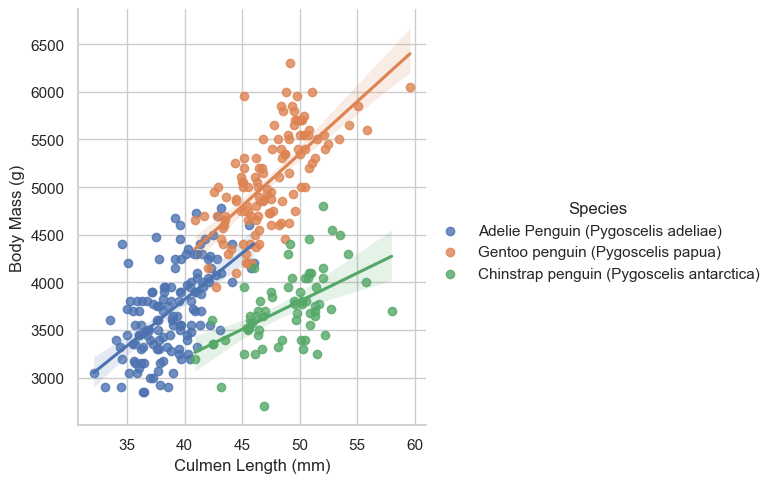

In [7]:
sns.lmplot(
    data=df,
    x='Culmen Length (mm)',
    y='Body Mass (g)',
    hue='Species'
)

### Relación entre profundidad de pico y masa corporal por especie

In [13]:
correlacion_por_especie = df.groupby('Species')[['Culmen Depth (mm)', 'Body Mass (g)']].corr().iloc[0::2, -1]

print(correlacion_por_especie)

Species                                                     
Adelie Penguin (Pygoscelis adeliae)        Culmen Depth (mm)    0.599125
Chinstrap penguin (Pygoscelis antarctica)  Culmen Depth (mm)    0.601949
Gentoo penguin (Pygoscelis papua)          Culmen Depth (mm)    0.718827
Name: Body Mass (g), dtype: float64


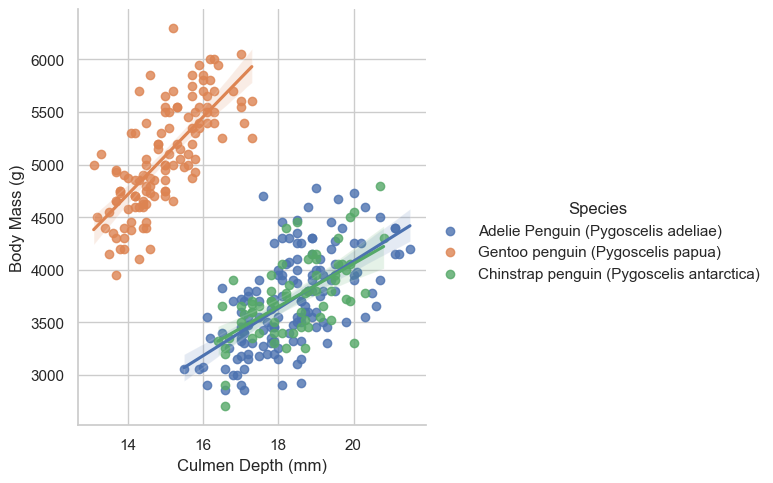

In [8]:
sns.lmplot(
    data=df,
    x='Culmen Depth (mm)',
    y='Body Mass (g)',
    hue='Species'
)

### Relación entre longitud de la aleta y masa corporal por especie

In [14]:
correlacion_por_especie = df.groupby('Species')[['Flipper Length (mm)', 'Body Mass (g)']].corr().iloc[0::2, -1]

print(correlacion_por_especie)

Species                                                       
Adelie Penguin (Pygoscelis adeliae)        Flipper Length (mm)    0.483622
Chinstrap penguin (Pygoscelis antarctica)  Flipper Length (mm)    0.640844
Gentoo penguin (Pygoscelis papua)          Flipper Length (mm)    0.702496
Name: Body Mass (g), dtype: float64


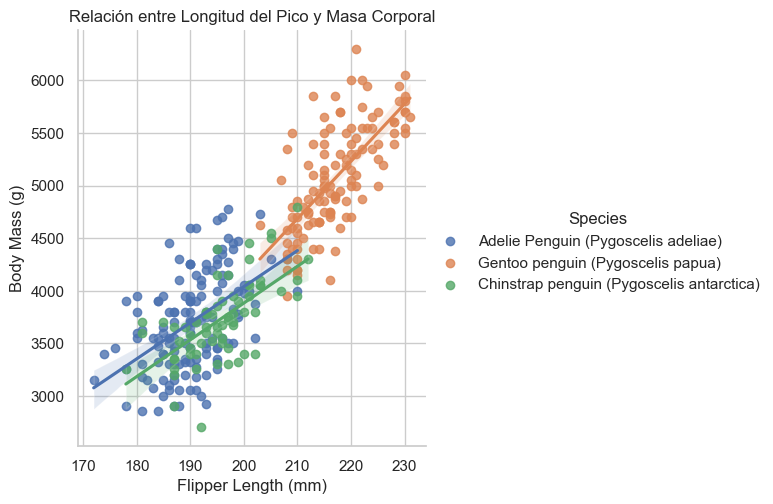

In [9]:
sns.lmplot(
    data=df,
    x='Flipper Length (mm)',
    y='Body Mass (g)',
    hue='Species'
)
plt.title('Relación entre Longitud del Pico y Masa Corporal')
plt.show()

### Diferencias morfológicas por especie

#### Longitud del pico por especie

In [9]:
df.groupby('Species')['Culmen Length (mm)'].agg(['mean', 'median', 'std'])

,mean,median,std
Species,,,
Adelie Penguin (Pygoscelis adeliae),38.801418,38.80,2.697538
Chinstrap penguin (Pygoscelis antarctica),48.788060,49.50,3.342904
Gentoo penguin (Pygoscelis papua),47.506557,47.25,3.094510


#### Profundidad del pico por especie

In [10]:
df.groupby('Species')['Culmen Depth (mm)'].agg(['mean', 'median', 'std'])

,mean,median,std
Species,,,
Adelie Penguin (Pygoscelis adeliae),18.327660,18.4,1.225917
Chinstrap penguin (Pygoscelis antarctica),18.404478,18.4,1.136106
Gentoo penguin (Pygoscelis papua),14.979508,15.0,0.984839


#### Longitud de las aletas por especie

In [11]:
df.groupby('Species')['Flipper Length (mm)'].agg(['mean', 'median', 'std'])

,mean,median,std
Species,,,
Adelie Penguin (Pygoscelis adeliae),190.290780,190.0,6.479130
Chinstrap penguin (Pygoscelis antarctica),195.671642,196.0,7.074041
Gentoo penguin (Pygoscelis papua),217.147541,216.0,6.496881
